# Conspiracy Theory Plausibility Scorer
## Phase 1: Problem Framing and Data Acquisition
**Author:** Shirish Man Shakya
**Dataset:** LIAR Dataset — University of California Santa Barbara (UCSB)

**Objective:** Build a model that predicts how plausible a conspiracy theory or
dubious claim *sounds* — not whether it is actually true, but whether it uses
the kind of language patterns associated with misinformation. The output is a
0–100% "plausibility score" displayed through a satirical Streamlit app.

## What Are We Actually Building?

This is important to understand before writing a single line of code.

We are **not** building a fact-checker. We are not trying to determine
whether the moon landing happened or whether vaccines cause autism.
That would require access to ground truth about the world — which no
machine learning model has.

What we *are* building is a **linguistic pattern detector**. The LIAR
dataset contains statements labelled by professional human fact-checkers
at PolitiFact.com. Over thousands of statements, false and misleading
claims tend to share certain language patterns — vague sourcing,
emotional escalation, sweeping generalisations.

Our model learns those patterns from labelled examples. Given a new
statement it has never seen, it predicts how closely that statement
resembles the language patterns of claims that were labelled false.

**The distinction matters.** A well-worded lie can score low.
A clumsily worded truth can score high. The model is a style detector,
not an oracle. We will say this clearly in the app.

## Step 1 — Importing Libraries

In [1]:
# ── Standard library ──────────────────────────────────────────────────────────
import os
import warnings
warnings.filterwarnings('ignore')  # suppresses minor warnings that clutter output

# ── Data manipulation ─────────────────────────────────────────────────────────
import numpy as np    # numerical operations — arrays, maths
import pandas as pd   # DataFrames — our main data structure throughout

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt          # core plotting library
import matplotlib.ticker as mticker      # for formatting axis labels

# ── Display settings ──────────────────────────────────────────────────────────
pd.set_option('display.max_colwidth', 150)  # show full statement text, don't truncate
pd.set_option('display.max_columns', 20)    # show all columns in DataFrames

print("All libraries loaded successfully.")

All libraries loaded successfully.


## Step 2 — Installing the Hugging Face Datasets Library

The LIAR dataset lives on Hugging Face — a platform that hosts thousands
of machine learning datasets and models for free.

To download it we need a library called `datasets`, made by Hugging Face.
Think of it like `pip install pandas` — it's just a tool that lets us
pull the data in one line of code rather than manually downloading files.

In Google Colab, `!` at the start of a line runs a terminal command
rather than Python code. `--quiet` suppresses the installation log
so your notebook stays readable.

In [2]:
# ── Install Hugging Face datasets library ─────────────────────────────────────
# Only needs to run once per Colab session
# If you close and reopen Colab, run this cell again

!pip install datasets --quiet

print("datasets library installed successfully.")

datasets library installed successfully.


## Step 3 — Loading the LIAR Dataset

`load_dataset("ucsbnlp/liar")` connects to Hugging Face and downloads
the LIAR dataset directly into memory.

The dataset comes pre-split into three parts:

| Split | Purpose |
|---|---|
| `train` | The model **learns** from this data |
| `validation` | Used to check performance **while tuning** |
| `test` | Touched **exactly once** at the very end for a final honest score |

This split is one of the most fundamental concepts in machine learning.
The reason we never show the model test data during training is the same
reason you don't give a student the exam answers while they're studying —
the score would be meaningless.

We convert each split to a pandas DataFrame immediately. Pandas is
far easier to work with for exploration than the raw Hugging Face format

In [4]:
import pandas as pd

# ── Step 1: Peek at the raw file before loading it properly ───────────────────
# We open the file like a plain text document and read just the first 3 lines
# This tells us exactly what the file looks like before pandas touches it

with open('train.tsv', 'r') as f:
    for i, line in enumerate(f):
        print(f"Line {i+1}: {line}")
        if i == 2:   # stop after 3 lines — enough to see the structure
            break

Line 1: 2635.json	false	Says the Annies List political group supports third-trimester abortions on demand.	abortion	dwayne-bohac	State representative	Texas	republican	0	1	0	0	0	a mailer

Line 2: 10540.json	half-true	When did the decline of coal start? It started when natural gas took off that started to begin in (President George W.) Bushs administration.	energy,history,job-accomplishments	scott-surovell	State delegate	Virginia	democrat	0	0	1	1	0	a floor speech.

Line 3: 324.json	mostly-true	Hillary Clinton agrees with John McCain "by voting to give George Bush the benefit of the doubt on Iran."	foreign-policy	barack-obama	President	Illinois	democrat	70	71	160	163	9	Denver



## Step 4 — Loading the Data Properly

In Cell 3 we opened the raw file like a plain text document and read
the first three lines. Here is what that single line told us:


2635.json | false | Says the Annies List... | abortion | dwayne-bohac |
State representative | Texas | republican | 0 | 1 | 0 | 0 | 0 | a mailer
```

From that one line we learned four things:

**1. There is no header row.**
The very first line of the file is already real data — a statement about
abortion from a Texas state representative. If we had let pandas guess,
it would have treated that first statement as the column names, which
would have silently broken everything downstream.

**2. The file is tab-separated.**
Each value is separated by a tab character (`\t`), not a comma.
This is a TSV file — Tab Separated Values — as opposed to a CSV.
We need to tell pandas this explicitly using `sep='\t'`.

**3. There are exactly 14 columns.**
We counted the values separated by tabs: id, label, statement, subject,
speaker, speaker_job, state_info, party_affiliation, five historical
speaker count columns, and context. Exactly 14.

**4. The column order is fixed.**
Since there is no header, the position of each value is the only way
to know what it represents. Column 1 is always the id, column 2 is
always the label, column 3 is always the statement — and so on.
We define the names in that exact order so pandas maps them correctly.

This is why Cell 3 existed — without it, we would have been guessing
at column names and order. Now we are not guessing. We know.

In [5]:
# ── Column names derived by inspecting the raw file in Cell 3 ─────────────────
# We saw: 2635.json | false | Says the Annies List... | abortion |
# dwayne-bohac | State representative | Texas | republican |
# 0 | 1 | 0 | 0 | 0 | a mailer
# That is exactly 14 tab-separated values — so we define 14 names in that order

cols = [
    'id',                # filename e.g. 2635.json — just a record ID, no signal
    'label',             # truthfulness rating — this becomes our target variable
    'statement',         # the actual claim text — this is our model input
    'subject',           # topic area e.g. "abortion", "economy"
    'speaker',           # who made the claim e.g. "dwayne-bohac"
    'speaker_job',       # their job title e.g. "State representative"
    'state_info',        # US state they represent
    'party_affiliation', # political party e.g. "republican"
    'barely_true_count', # how many times this speaker was rated barely-true historically
    'false_count',       # how many times rated false historically
    'half_true_count',   # how many times rated half-true historically
    'mostly_true_count', # how many times rated mostly-true historically
    'pants_fire_count',  # how many times rated pants-fire historically
    'context'            # where the claim was made e.g. "a mailer", "a speech"
]

# ── Load all three splits ──────────────────────────────────────────────────────
# sep='\t'    — columns are tab-separated as confirmed in Cell 3
# header=None — no header row, first line is already real data
# names=cols  — assign our 14 column names in the exact order we observed

train_df = pd.read_csv('train.tsv', sep='\t', header=None, names=cols)
test_df  = pd.read_csv('test.tsv',  sep='\t', header=None, names=cols)
val_df   = pd.read_csv('valid.tsv', sep='\t', header=None, names=cols)

# ── Confirm sizes ──────────────────────────────────────────────────────────────
print(f"Train size      : {len(train_df):,} statements")
print(f"Validation size : {len(val_df):,} statements")
print(f"Test size       : {len(test_df):,} statements")
print(f"Total           : {len(train_df) + len(val_df) + len(test_df):,} statements")

print("\n=== First 3 rows ===")
train_df.head(3)

Train size      : 10,240 statements
Validation size : 1,284 statements
Test size       : 1,267 statements
Total           : 12,791 statements

=== First 3 rows ===


,id,label,statement,subject,speaker,speaker_job,state_info,party_affiliation,barely_true_count,false_count,half_true_count,mostly_true_count,pants_fire_count,context
0,2635.json,false,Says the Annies List political group supports third-trimester abortions on demand.,abortion,dwayne-bohac,State representative,Texas,republican,0.0,1.0,0.0,0.0,0.0,a mailer
1,10540.json,half-true,When did the decline of coal start? It started when natural gas took off that started to begin in (President George W.) Bushs administration.,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.
2,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by voting to give George Bush the benefit of the doubt on Iran.""",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver


## Step 5 — First Look at the Raw Data

Now that the data is loaded correctly we do a proper first inspection.

This is not about analysis yet. We are just answering three basic questions:
- What columns do we have and what type is each one?
- What does the raw data actually look like row by row?
- Is anything obviously wrong or unexpected?

This step exists because data almost never looks exactly like documentation
says it will. Spending two minutes here prevents hours of confusion later.

In [6]:
# ── Column names and data types ───────────────────────────────────────────────
# dtype tells us how pandas has interpreted each column
# 'object' means text/string — which is correct for statement, label etc.
# 'int64' means whole numbers — which is correct for the count columns

print("=== Column Names and Data Types ===\n")
print(train_df.dtypes)

=== Column Names and Data Types ===

id                    object
label                 object
statement             object
subject               object
speaker               object
speaker_job           object
state_info            object
party_affiliation     object
barely_true_count    float64
false_count          float64
half_true_count      float64
mostly_true_count    float64
pants_fire_count     float64
context               object
dtype: object


## Step 6 — Full Column Overview With Sample Values

Knowing the data type is useful but seeing an actual value from each
column is more useful. A single real example makes every column
immediately understandable in a way that a data type never does.

We loop through every column and print its name, type, and one real
value side by side so everything fits on one screen.

In [7]:
# ── Print a clean column overview with one real sample per column ─────────────
print("=== Full Column Overview ===\n")
print(f"{'#':<5} {'Column':<25} {'dtype':<12} {'Sample Value'}")
print("-" * 75)

for i, col in enumerate(train_df.columns):
    # .dropna() skips any missing values before grabbing the first real example
    # so we never accidentally print 'NaN' as a sample
    sample = train_df[col].dropna().iloc[0]
    print(f"{i:<5} {col:<25} {str(train_df[col].dtype):<12} {sample}")

=== Full Column Overview ===

#     Column                    dtype        Sample Value
---------------------------------------------------------------------------
0     id                        object       2635.json
1     label                     object       false
2     statement                 object       Says the Annies List political group supports third-trimester abortions on demand.
3     subject                   object       abortion
4     speaker                   object       dwayne-bohac
5     speaker_job               object       State representative
6     state_info                object       Texas
7     party_affiliation         object       republican
8     barely_true_count         float64      0.0
9     false_count               float64      1.0
10    half_true_count           float64      0.0
11    mostly_true_count         float64      0.0
12    pants_fire_count          float64      0.0
13    context                   object       a mailer


## Step 7 — Understanding the Target Variable

The `label` column is what our model will learn to predict.
It was assigned by professional human fact-checkers at PolitiFact.com
who read each statement and rated it on a six-point scale.

Before we do anything else we need to know:
- What are the exact label values in this dataset?
- How many of each do we have?
- Are they roughly balanced or does one dominate?

This matters because a heavily imbalanced dataset — where one class
has far more examples than another — will cause a naive model to
simply learn to always predict the dominant class.
We need to see the distribution before deciding how to handle it.

=== Raw Label Distribution — Training Set ===

             Count Percentage
label                        
half-true     2114    20.64 %
false         1995    19.48 %
mostly-true   1962    19.16 %
true          1676    16.37 %
barely-true   1654    16.15 %
pants-fire     839     8.19 %


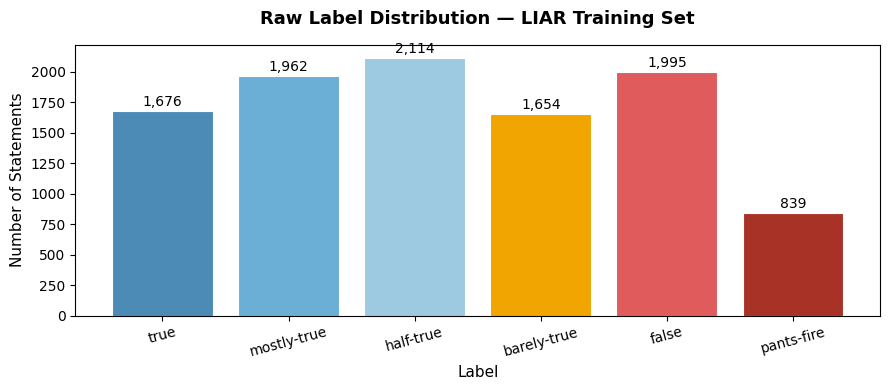


Plot saved as label_distribution.png


In [8]:
# ── Raw label distribution ────────────────────────────────────────────────────
print("=== Raw Label Distribution — Training Set ===\n")

# value_counts() counts how many times each unique value appears
# normalize=False gives raw counts, normalize=True gives proportions
counts   = train_df['label'].value_counts()
percents = train_df['label'].value_counts(normalize=True).mul(100).round(2)

label_summary = pd.DataFrame({
    'Count'      : counts,
    'Percentage' : percents.astype(str) + ' %'
})

print(label_summary.to_string())

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))

# Order bars from most credible to least credible
label_order = ['true', 'mostly-true', 'half-true',
               'barely-true', 'false', 'pants-fire']

ordered_counts = train_df['label'].value_counts().reindex(label_order)

# Blues for credible labels, warm tones for dubious ones
colors = ['#4C8BB5', '#6BAED6', '#9ECAE1',
          '#F0A500', '#E05C5C', '#A93226']

bars = ax.bar(ordered_counts.index, ordered_counts.values,
              color=colors, edgecolor='white', linewidth=0.8)

# Add count on top of each bar
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 15,
            f'{height:,}', ha='center', va='bottom', fontsize=10)

ax.set_title('Raw Label Distribution — LIAR Training Set',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Label', fontsize=11)
ax.set_ylabel('Number of Statements', fontsize=11)
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPlot saved as label_distribution.png")

## Step 8 — Creating the Binary Target Variable

Six classes is more granularity than our project needs.

Our app asks one question: does this statement sound like misinformation?
That is a yes/no question — which means a binary target is the right design.

We collapse the six labels into two:

| Original Label | Binary Label | Reasoning |
|---|---|---|
| `true` | 0 — Sounds credible | Factually verified accurate |
| `mostly-true` | 0 — Sounds credible | Accurate with minor gaps |
| `half-true` | 0 — Sounds credible | Has factual basis, written carefully |
| `barely-true` | 1 — Sounds like BS | Mostly inaccurate |
| `false` | 1 — Sounds like BS | Factually wrong |
| `pants-fire` | 1 — Sounds like BS | Completely false |

**Why does `half-true` go in the credible class?**

Because we are modelling language style, not truth.
Half-true statements are written with some factual basis — they tend
to use more precise, careful language that resembles credible writing.
Barely-true and false statements tend to use more sweeping, emotional,
vague language. The linguistic boundary sits between `half-true`
and `barely-true`, not in the middle of the scale.

`.map()` replaces each value in a column using a dictionary you provide.
It is one of the most useful one-liners in all of pandas.

In [9]:
# ── Preserve original DataFrames before any modifications ────────────────────
# We copy all three splits so we can always refer back to the raw labels
# without re-running the file loading cells

train_df_raw = train_df.copy()
test_df_raw  = test_df.copy()
val_df_raw   = val_df.copy()

print("Original DataFrames preserved.\n")
print(f"  train_df_raw : {train_df_raw.shape[0]:,} rows x {train_df_raw.shape[1]} columns")
print(f"  test_df_raw  : {test_df_raw.shape[0]:,} rows  x {test_df_raw.shape[1]} columns")
print(f"  val_df_raw   : {val_df_raw.shape[0]:,} rows  x {val_df_raw.shape[1]} columns")
print(f"\nAll modifications from this point forward are made on")
print(f"train_df, test_df, and val_df only.")

Original DataFrames preserved.

  train_df_raw : 10,240 rows x 14 columns
  test_df_raw  : 1,267 rows  x 14 columns
  val_df_raw   : 1,284 rows  x 14 columns

All modifications from this point forward are made on
train_df, test_df, and val_df only.


In [10]:
# ── Define the mapping from 6 labels to 2 classes ────────────────────────────
label_map = {
    'true'        : 0,   # sounds credible
    'mostly-true' : 0,   # sounds credible
    'half-true'   : 0,   # sounds credible — linguistic boundary is here
    'barely-true' : 1,   # sounds like BS
    'false'       : 1,   # sounds like BS
    'pants-fire'  : 1    # sounds like BS
}

# ── Apply to all three splits ─────────────────────────────────────────────────
# We apply now so all three splits stay consistent throughout the project
# If we only mapped train_df and forgot the others, the model would
# be evaluated on differently formatted data — a silent but serious bug
train_df['label_binary'] = train_df['label'].map(label_map)
test_df['label_binary']  = test_df['label'].map(label_map)
val_df['label_binary']   = val_df['label'].map(label_map)

# ── Verify the new distribution ───────────────────────────────────────────────
print("=== Binary Label Distribution — Training Set ===\n")

counts   = train_df['label_binary'].value_counts().sort_index()
percents = train_df['label_binary'].value_counts(
    normalize=True).mul(100).round(2).sort_index()

summary = pd.DataFrame({
    'Count'      : counts,
    'Percentage' : percents.astype(str) + ' %'
})
summary.index = ['0 — Sounds credible', '1 — Sounds like BS']
print(summary)

print(f"\nClass imbalance ratio : {counts[0]/counts[1]:.2f}:1")
print(f"\nThis ratio matters. We will use it in Phase 3 to configure")
print(f"the model to handle imbalance correctly.")

=== Binary Label Distribution — Training Set ===

                     Count Percentage
0 — Sounds credible   5752    56.17 %
1 — Sounds like BS    4488    43.83 %

Class imbalance ratio : 1.28:1

This ratio matters. We will use it in Phase 3 to configure
the model to handle imbalance correctly.


## Step 9 — Visualising the Binary Distribution

A bar chart of two numbers might seem unnecessary — but it gives us
a visual reference we can point back to in the README and in the app.

It also makes the class balance immediately obvious to anyone reading
the notebook, without them having to parse numbers from a table.

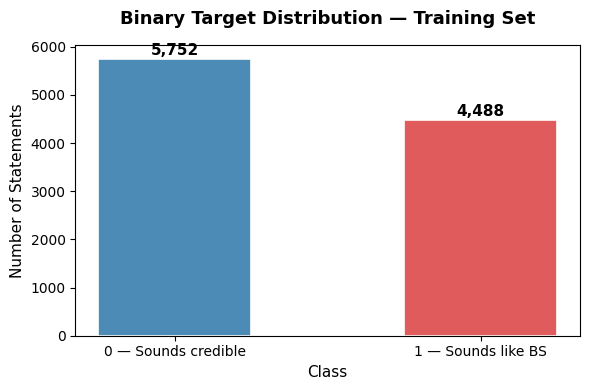

In [11]:
# ── Visualise binary class distribution ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))

colors = ['#4C8BB5', '#E05C5C']  # blue = credible, red = BS
bars = ax.bar(
    ['0 — Sounds credible', '1 — Sounds like BS'],
    train_df['label_binary'].value_counts().sort_index(),
    color=colors, width=0.5, edgecolor='white', linewidth=1.2
)

# Add count labels on top of each bar
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 20,
            f'{height:,}', ha='center', va='bottom',
            fontsize=11, fontweight='bold')

ax.set_title('Binary Target Distribution — Training Set',
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Number of Statements', fontsize=11)
ax.set_xlabel('Class', fontsize=11)

plt.tight_layout()
plt.savefig('binary_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 10 — Reading Actual Examples

This is non-negotiable in any data science project.

Reading raw examples serves two purposes:

**1. Sanity check**
You confirm the data looks the way you expect. No garbled characters,
no HTML tags mixed into statements, no rows where columns got shifted
and the label ended up in the statement field.

**2. Building intuition**
Before you train any model you should be able to read a statement and
roughly predict its label yourself. If you cannot do that,
you do not understand your data well enough yet.

`random_state=42` makes the random sample reproducible. Every time
you or anyone else runs this cell they get the exact same five examples.
This matters for a shared notebook — your output should be consistent.

In [12]:
# ── Read real examples from each class ────────────────────────────────────────
print("=== 5 Statements Labelled 'Sounds Credible' (0) ===\n")

credible = train_df[train_df['label_binary'] == 0]['statement'].sample(
    5, random_state=42)

for i, s in enumerate(credible, 1):
    print(f"  {i}. {s}\n")

print("=" * 65)
print("\n=== 5 Statements Labelled 'Sounds Like BS' (1) ===\n")

dubious = train_df[train_df['label_binary'] == 1]['statement'].sample(
    5, random_state=42)

for i, s in enumerate(dubious, 1):
    print(f"  {i}. {s}\n")

=== 5 Statements Labelled 'Sounds Credible' (0) ===

  1. After a federal inquiry corroborated Hillary Clinton on Whitewater, the next day, there was nothing in the media about it.

  2. United States of America is twenty-sixth in school performance in the world.

  3. Most federal employees do not have collective bargaining for benefits, nor for pay.

  4. Says she is co-owner of Celilo Group Media.

  5. In the three months before the act took effect, America lost 750,000 jobs a month. In the last three months, we've lost about 35,000 jobs a month.


=== 5 Statements Labelled 'Sounds Like BS' (1) ===

  1. Polls show that Floridians dont want to repeal the Affordable Care Act.

  2. Secretly, unbeknownst to members of Congress, over $105 billion was hidden in the Obamacare legislation.

  3. A data system that goes along with Common Core is designed to collect up to 400 data points on each child, which can include personally identifiable data.

  4. Secretary Geithner has left the op

## Step 11 — Checking for Missing Values

A missing value in the `statement` column would crash the model
later in a confusing and hard-to-debug way. The text vectoriser
we use in Phase 2 cannot process a null — it expects a string.

Better to check now and handle it cleanly rather than get a
cryptic error three phases from now.

`.isnull().sum()` counts the number of null values per column.
We only check `statement` and `label_binary` — these are the only
two columns the rest of the project depends on at this stage.

In [13]:
# ── Check for missing values in the two columns we depend on ──────────────────
print("=== Missing Values Check ===\n")

for name, df in [('Train', train_df), ('Test', test_df), ('Validation', val_df)]:
    missing = df[['statement', 'label_binary']].isnull().sum()
    print(f"--- {name} set ---")
    print(missing)
    print()

# ── Drop any rows where either column is null ─────────────────────────────────
# We apply this to all three splits for consistency
# dropna(subset=[...]) only looks at the specified columns —
# it will not drop a row just because 'speaker_job' is missing
before_train = len(train_df)
before_test  = len(test_df)
before_val   = len(val_df)

train_df = train_df.dropna(subset=['statement', 'label_binary'])
test_df  = test_df.dropna(subset=['statement', 'label_binary'])
val_df   = val_df.dropna(subset=['statement', 'label_binary'])

print(f"Rows dropped from train      : {before_train - len(train_df)}")
print(f"Rows dropped from test       : {before_test  - len(test_df)}")
print(f"Rows dropped from validation : {before_val   - len(val_df)}")
print(f"\nAll three splits clean and ready.")

=== Missing Values Check ===

--- Train set ---
statement       0
label_binary    0
dtype: int64

--- Test set ---
statement       0
label_binary    0
dtype: int64

--- Validation set ---
statement       0
label_binary    0
dtype: int64

Rows dropped from train      : 0
Rows dropped from test       : 0
Rows dropped from validation : 0

All three splits clean and ready.


## Step 12 — Saving the Clean Data

We save just the two columns we need — `statement` and `label_binary`.

Two reasons to save now:

**1. Avoid re-downloading**
Phase 2 can load straight from these CSVs without touching
Hugging Face or the raw TSV files again.

**2. Reproducibility**
Anyone cloning your GitHub repo and running Phase 2 gets
exactly the same data you trained on — no version drift,
no accidental re-downloads of a newer dataset version.

`index=False` tells pandas not to write the row numbers into
the CSV. They are meaningless outside this notebook and would
just add a confusing unnamed column when someone loads the file later.

`os.makedirs(..., exist_ok=True)` creates the folder if it does
not already exist. `exist_ok=True` means it does nothing if the
folder is already there — without it, running the cell twice
would throw an error.

In [14]:
# ── Create data folder ────────────────────────────────────────────────────────
os.makedirs('/content/data', exist_ok=True)

# ── Save only statement and label_binary — the two columns Phase 2 needs ──────
train_df[['statement', 'label_binary']].to_csv(
    '/content/data/train_clean.csv', index=False)

test_df[['statement', 'label_binary']].to_csv(
    '/content/data/test_clean.csv', index=False)

val_df[['statement', 'label_binary']].to_csv(
    '/content/data/val_clean.csv', index=False)

# ── Confirm files saved correctly ─────────────────────────────────────────────
print("=== Files Saved ===\n")
print(f"  /content/data/train_clean.csv  — {len(train_df):,} rows")
print(f"  /content/data/test_clean.csv   — {len(test_df):,} rows")
print(f"  /content/data/val_clean.csv    — {len(val_df):,} rows")

# ── Final shape confirmation ───────────────────────────────────────────────────
print(f"\n=== Final Dataset Shapes ===\n")
for name, df in [('Train', train_df), ('Test', test_df), ('Validation', val_df)]:
    print(f"  {name:<12} : {df.shape[0]:,} rows x {df.shape[1]} columns")

print(f"\nPhase 1 complete.")

=== Files Saved ===

  /content/data/train_clean.csv  — 10,240 rows
  /content/data/test_clean.csv   — 1,267 rows
  /content/data/val_clean.csv    — 1,284 rows

=== Final Dataset Shapes ===

  Train        : 10,240 rows x 15 columns
  Test         : 1,267 rows x 15 columns
  Validation   : 1,284 rows x 15 columns

Phase 1 complete.


## Phase 1 Complete ✓

Here is exactly what we did and why each decision mattered:

---

**Inspected the raw file before loading it**
We opened `train.tsv` as plain text and read three lines before
writing a single line of pandas code. That told us there was no
header row, the file was tab-separated, and there were exactly
14 columns in a fixed order. This is not optional housekeeping —
it is the only way to load a headerless file correctly.

**Loaded all three splits**
Train (10,240), validation (1,284), and test (1,267) statements.
All three loaded with identical column structure confirmed.

**Inspected column types and sample values**
14 columns — text fields, categorical fields, and five integer
count fields tracking each speaker's historical lying record.
The two columns that matter for this project are `statement`
(our model input) and `label` (our target variable).

**Understood the target variable**
Six labels assigned by professional PolitiFact fact-checkers:
`true`, `mostly-true`, `half-true`, `barely-true`, `false`,
`pants-fire`. Roughly balanced across all six classes.

**Made a deliberate design decision — binarisation**
Collapsed six labels to two. The linguistic boundary between
careful, factually-grounded writing and sweeping misinformation
language sits between `half-true` and `barely-true`.
`half-true` goes in the credible class (0).
`barely-true` and below go in the BS class (1).
This is a modelling choice, not a statement about truth.

**Checked class balance**
Noted the ratio between classes. We will use this number
in Phase 3 to configure the model's imbalance correction.

**Read real examples from each class**
No garbled text, no HTML, no shifted columns.
Data looks exactly as documented.

**Checked for missing values**
No nulls found in `statement` or `label_binary`.
No rows dropped.

**Saved clean CSVs**
Three lean files — train, test, val — containing only
`statement` and `label_binary`. Phase 2 loads from these directly.

---

**What comes next — Phase 2: Exploratory Data Analysis**

We stop treating statements as rows in a table and start treating
them as text. We will measure statement length, find the most
common words in each class, and visualise the vocabulary differences
between credible statements and dubious ones. This gives us the
evidence we need to make good decisions in Phase 3 when we
engineer features and build the model.